<a href="https://colab.research.google.com/github/Aleenapshaji/adult_income_predictions/blob/main/Copy_of_Case_Study_HOUSE_PRICING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

from sklearn.feature_selection import mutual_info_regression

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
House_df = pd.read_csv("/content/drive/MyDrive/AI ML Course/Data/House_Pricing.csv")

In [16]:
House_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [17]:
House_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [18]:
House_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


### ▶ "No of times visited" : Has large amount of missing values hence we are dropping that column

In [19]:
House_df = House_df.drop(columns = "No of Times Visited")

In [20]:
House_df

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,Fair,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,Fair,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,Fair,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,Fair,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [21]:
# Only filling missing values in the Sale Price column
House_df["Sale Price"] = House_df["Sale Price"].fillna(House_df["Sale Price"].mean())
# "sales price" can be of an average value
House_df["No of Bathrooms"] = House_df["No of Bathrooms"].fillna(House_df["No of Bathrooms"].median())
House_df["Flat Area (in Sqft)"] = House_df["Flat Area (in Sqft)"].fillna(House_df["Flat Area (in Sqft)"].median())
House_df["Lot Area (in Sqft)"] = House_df["Lot Area (in Sqft)"].fillna(House_df["Lot Area (in Sqft)"].median())
House_df["Area of the House from Basement (in Sqft)"] = House_df["Area of the House from Basement (in Sqft)"].fillna(House_df["Area of the House from Basement (in Sqft)"].median())
House_df["Zipcode"] = House_df["Zipcode"].fillna(House_df["Zipcode"].mean())
House_df["Latitude"] = House_df["Latitude"].fillna(House_df["Latitude"].mean())
House_df["Longitude"] = House_df["Longitude"].fillna(House_df["Longitude"].mean())
House_df["Living Area after Renovation (in Sqft)"] = House_df["Living Area after Renovation (in Sqft)"].fillna(House_df["Living Area after Renovation (in Sqft)"].mean())

In [22]:
House_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


# Finding Out the OUtliers

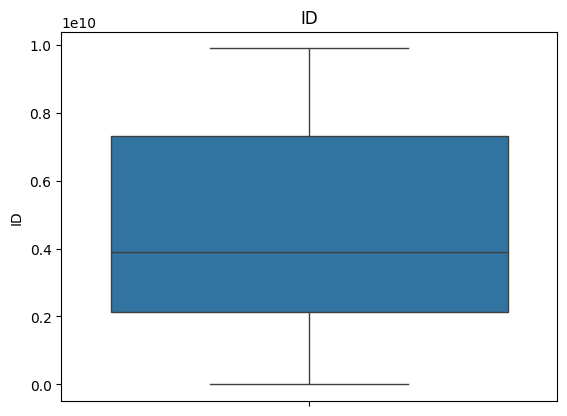

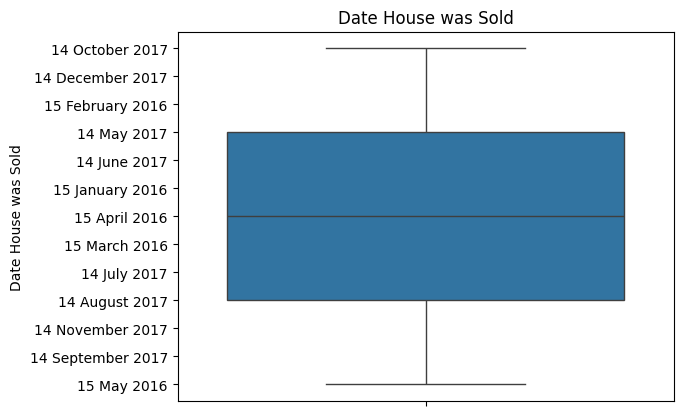

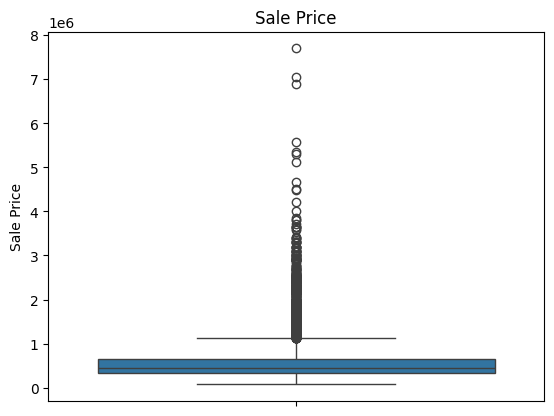

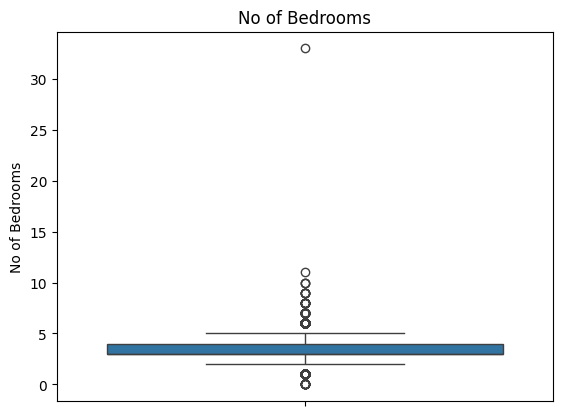

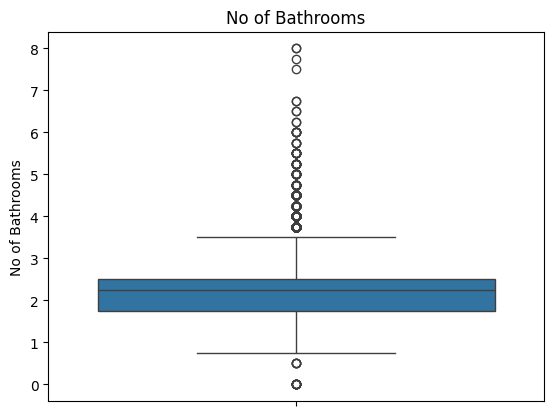

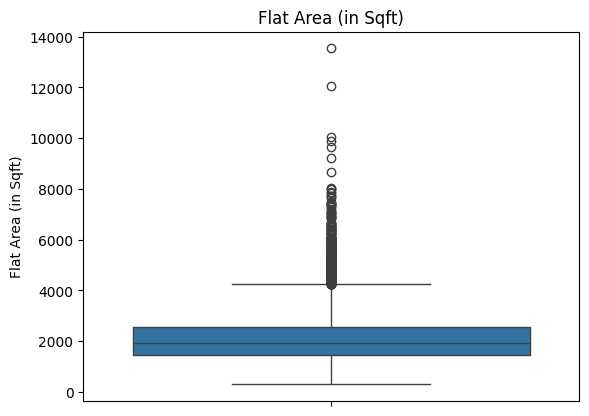

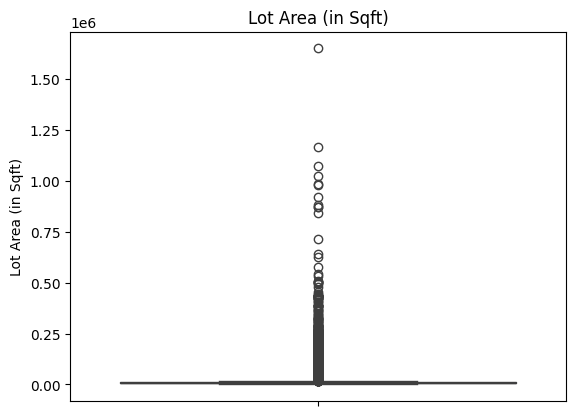

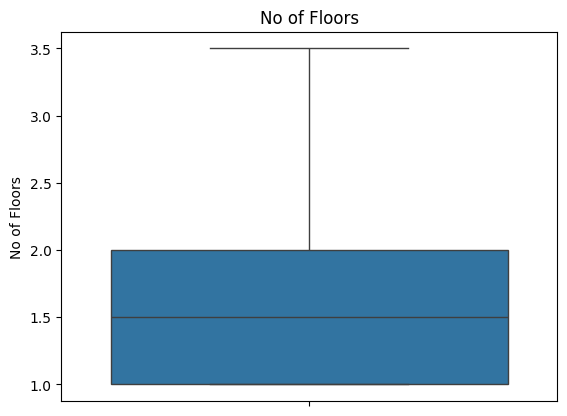

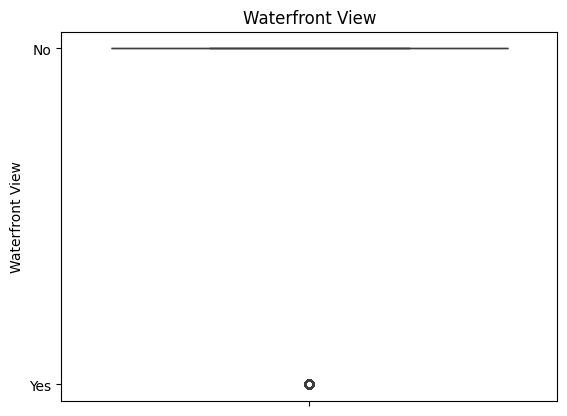

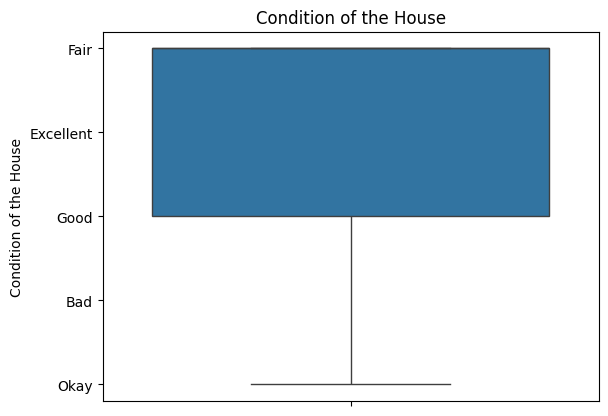

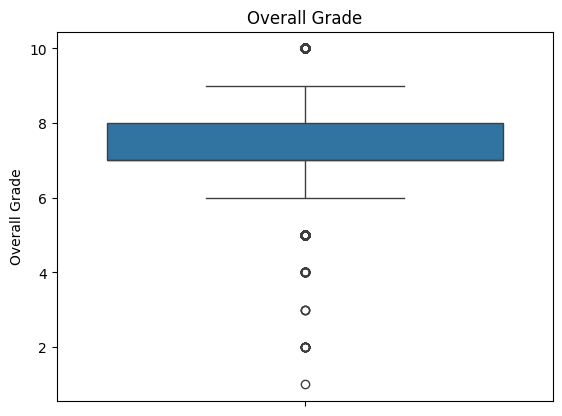

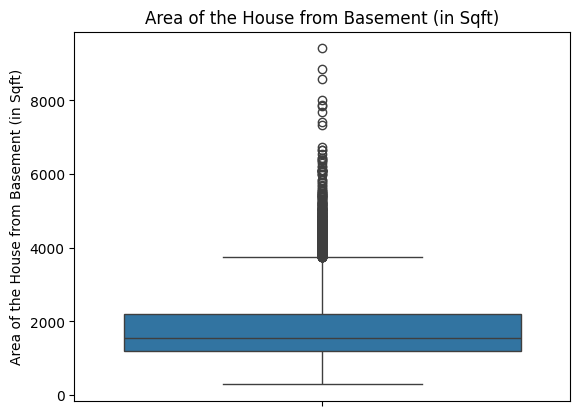

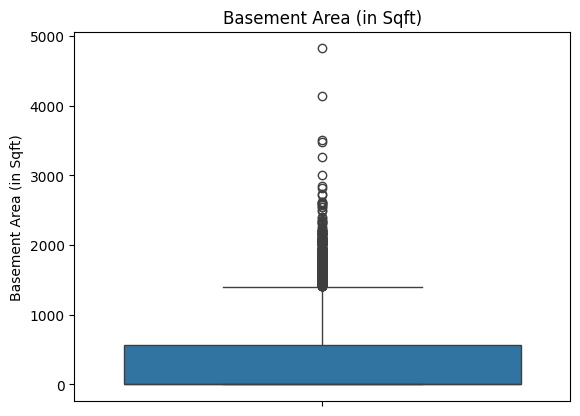

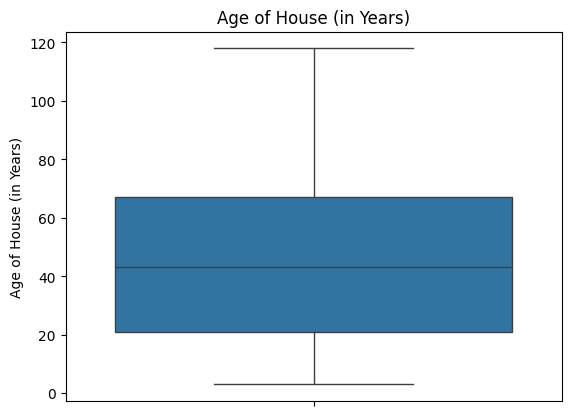

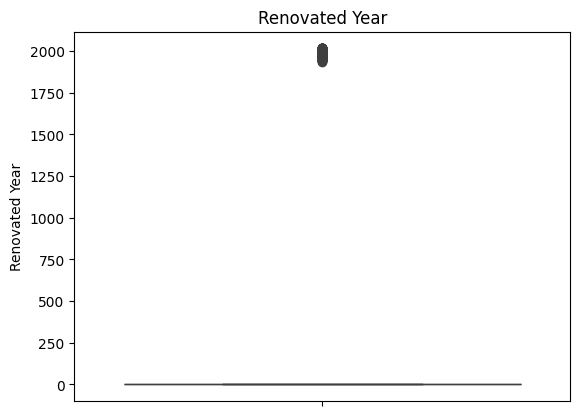

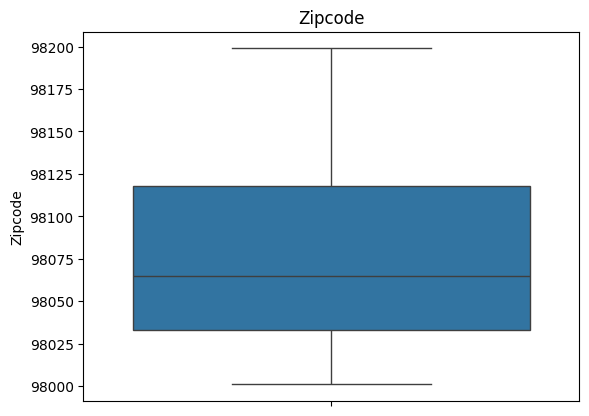

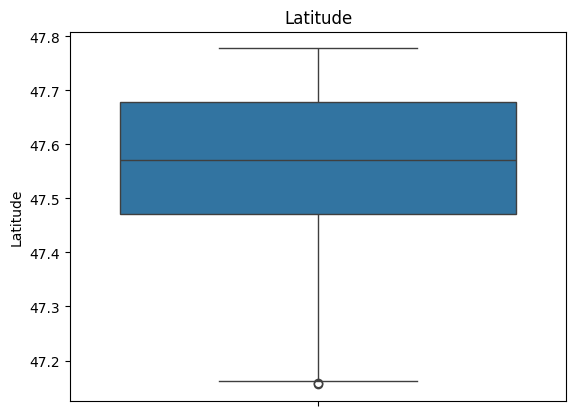

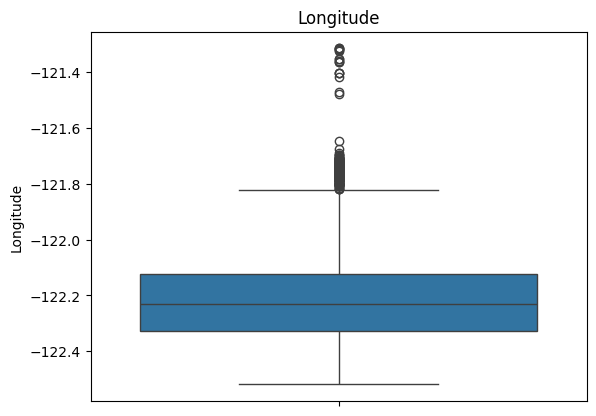

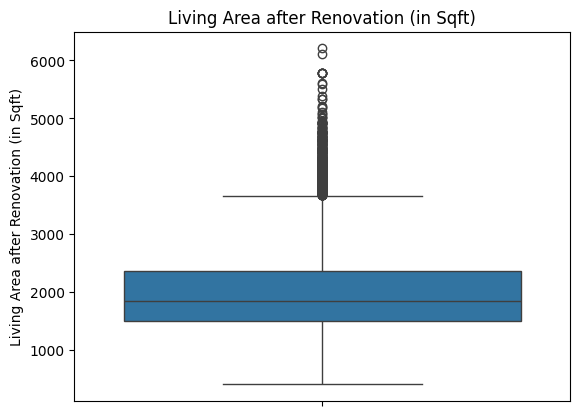

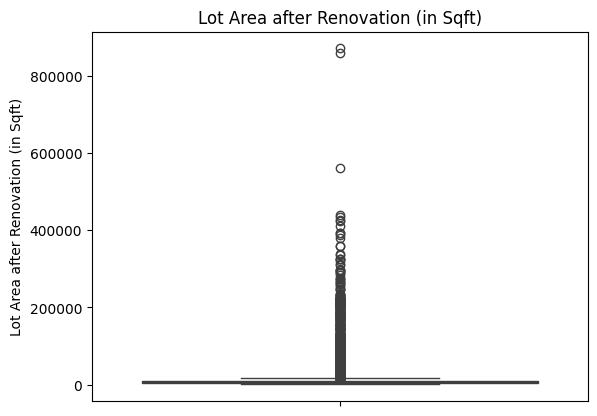

In [23]:
for columns in House_df:
  sns.boxplot(House_df[columns])
  plt.title(columns)
  plt.show()

#Clipping the Outliers To the UpperBound Or Lowerbound

In [24]:
for column in House_df.select_dtypes(include="number").columns: #loop for column
    Q1 = House_df[column].quantile(0.25)
    Q3 = House_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    has_outliers = ((House_df[column] < lower_bound) | (House_df[column] > upper_bound)).any() #checking for Outliers

    if has_outliers:
        House_df[column] = House_df[column].clip(lower=lower_bound, upper=upper_bound)

#After clipping

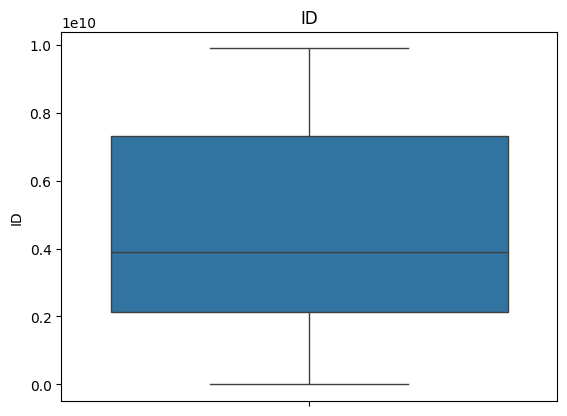

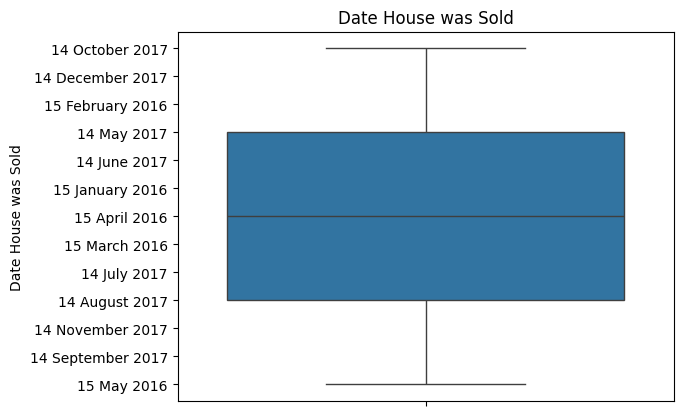

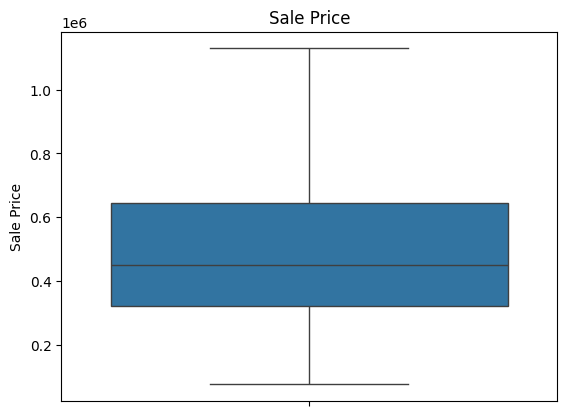

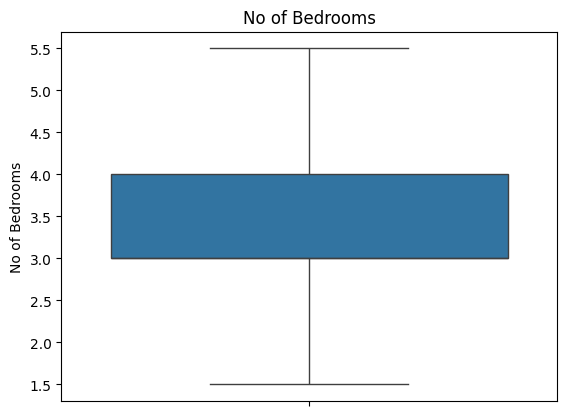

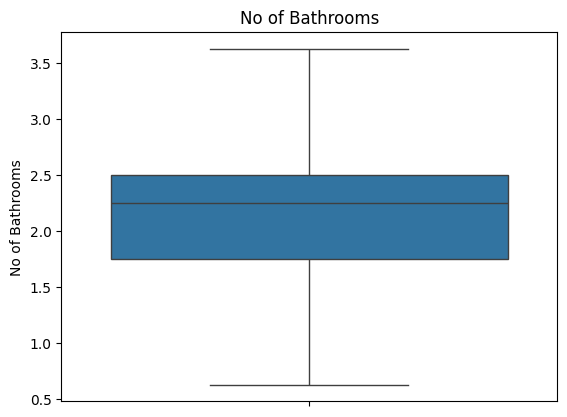

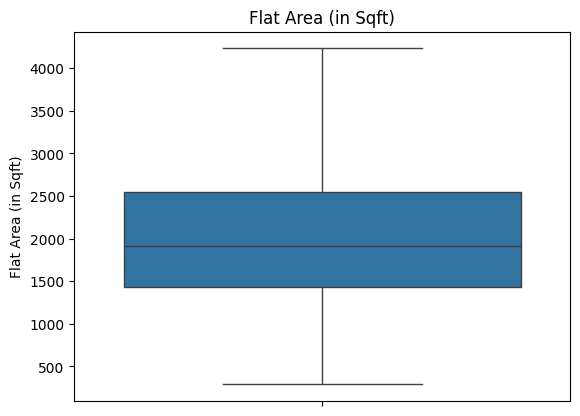

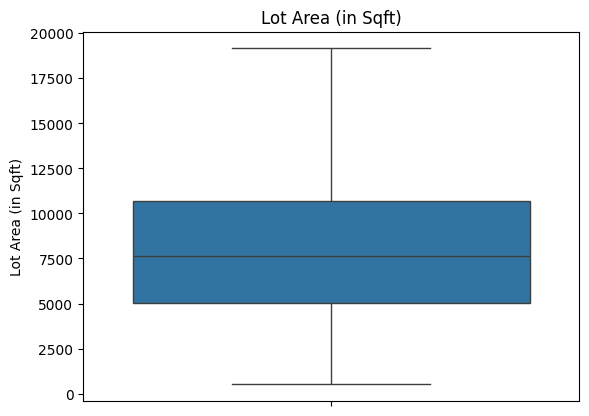

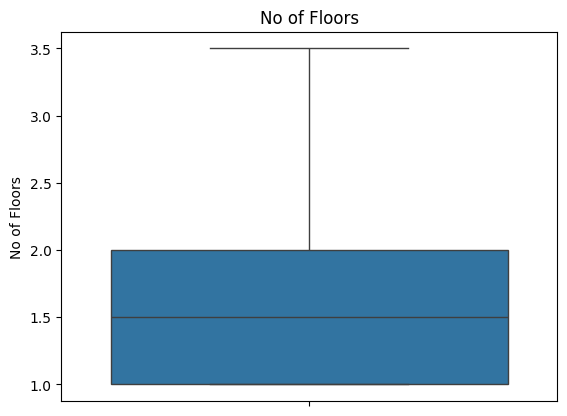

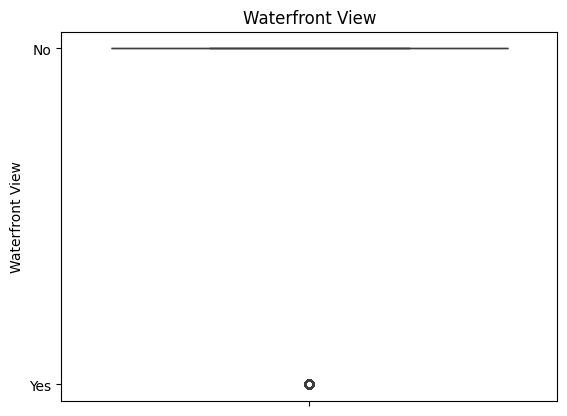

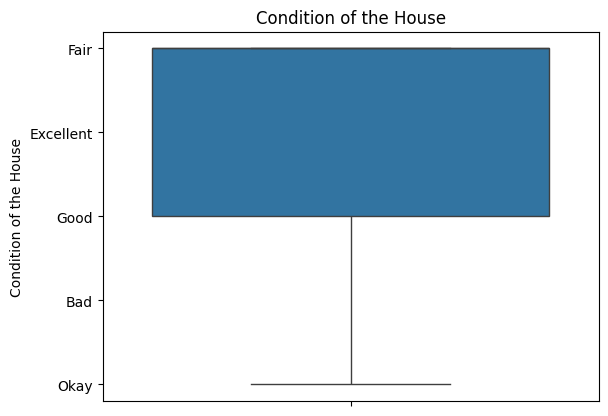

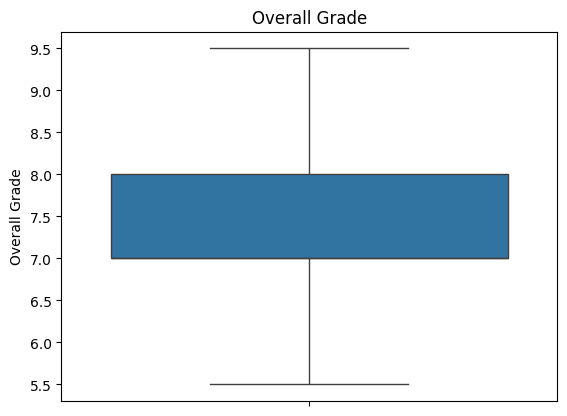

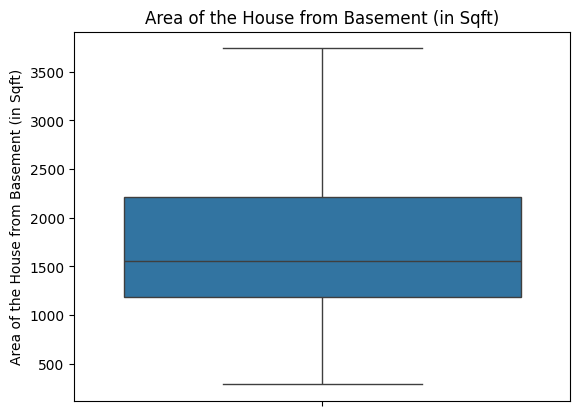

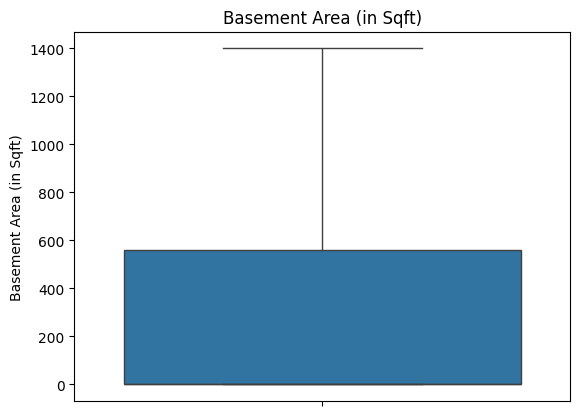

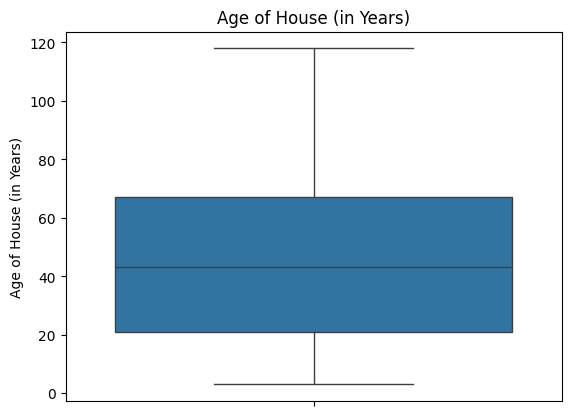

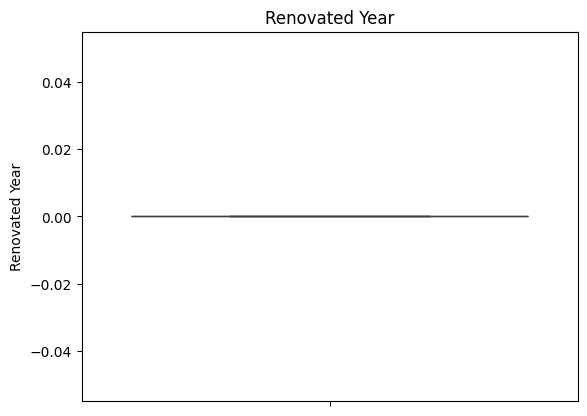

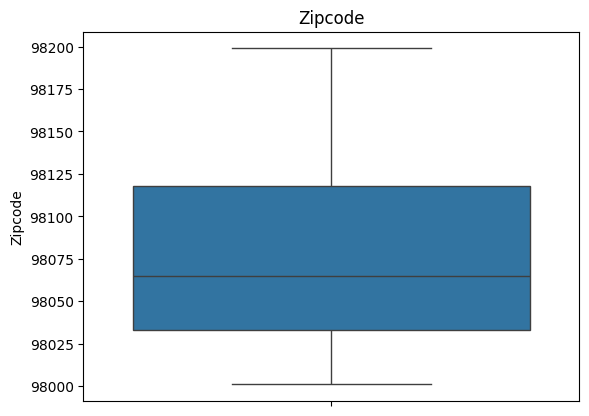

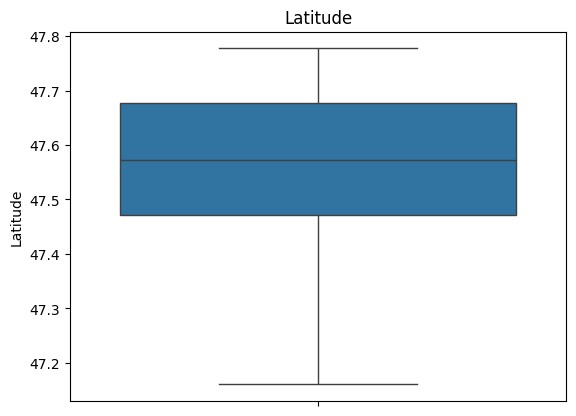

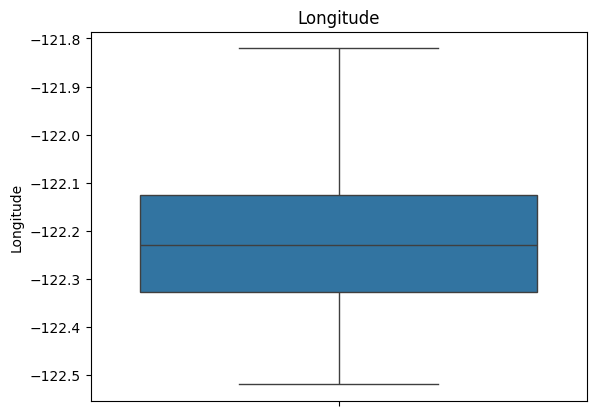

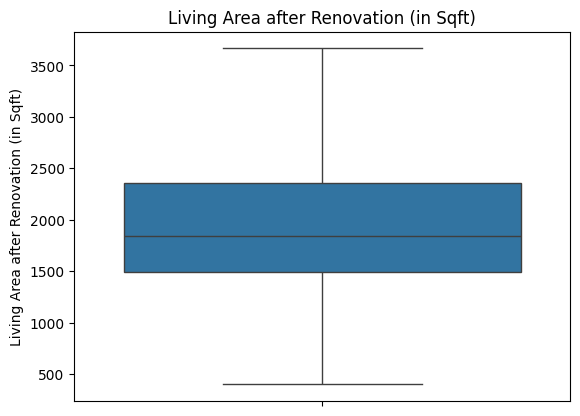

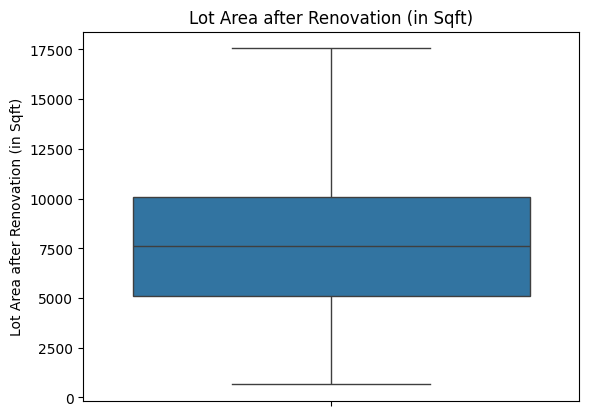

In [25]:
for columns in House_df:
  sns.boxplot(House_df[columns])
  plt.title(columns)
  plt.show()

#  Tranformation Part

In [26]:
# fetching numerical columns
num_cols = House_df.select_dtypes(include = ['int64','float64']).columns
# fetching cateogrical data
cat_cols = House_df.select_dtypes(include = ['object']).columns
print(num_cols)
print(cat_cols)

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')
Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')


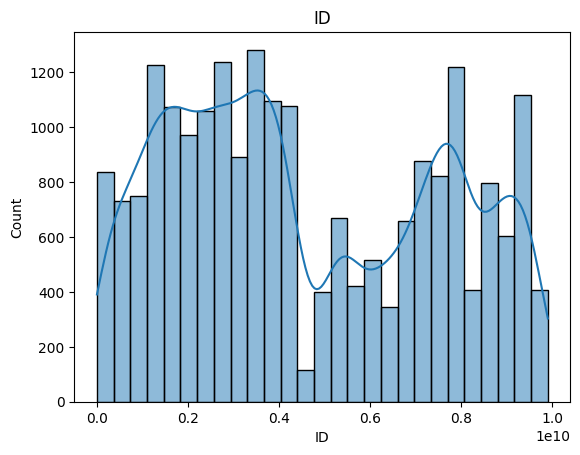

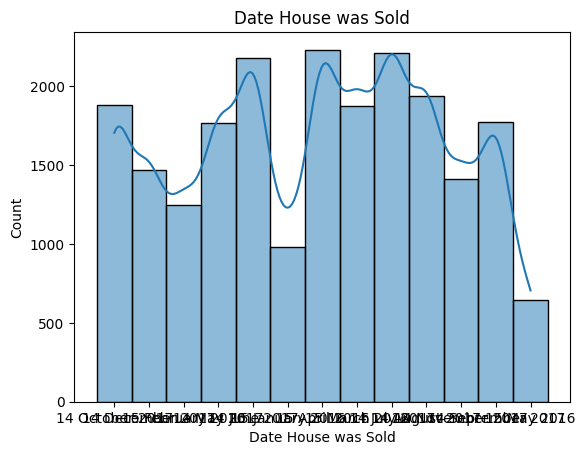

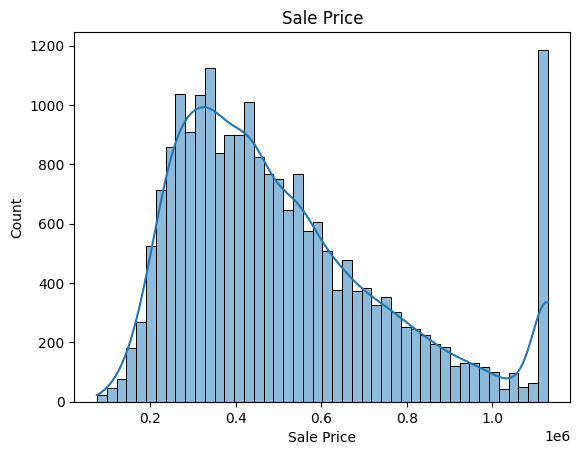

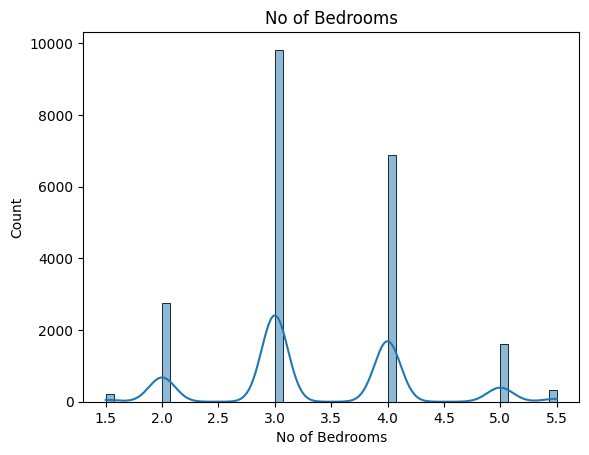

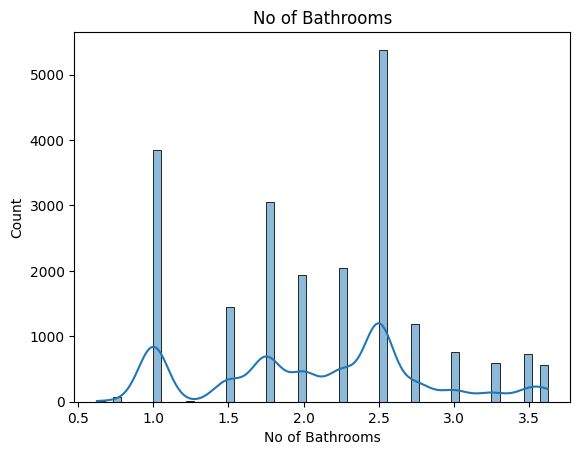

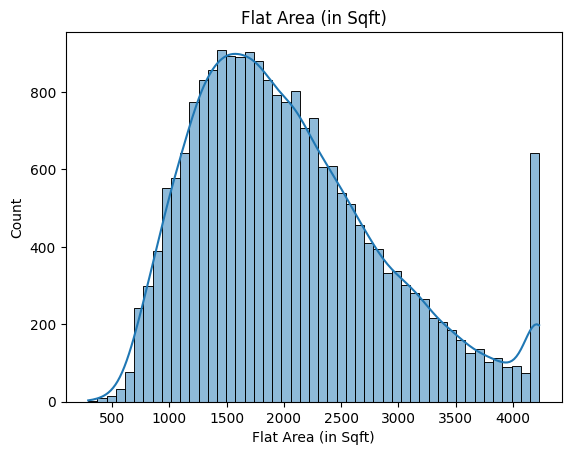

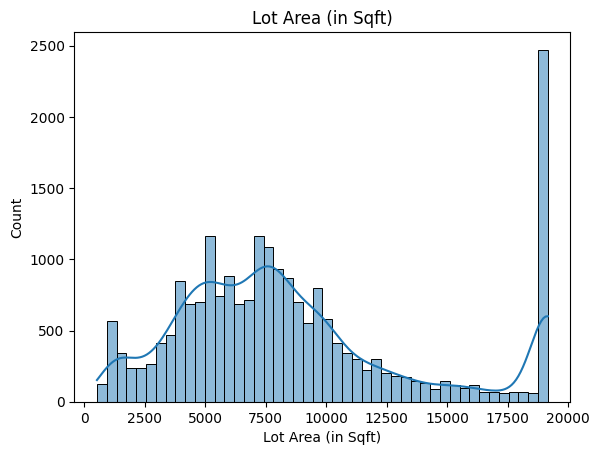

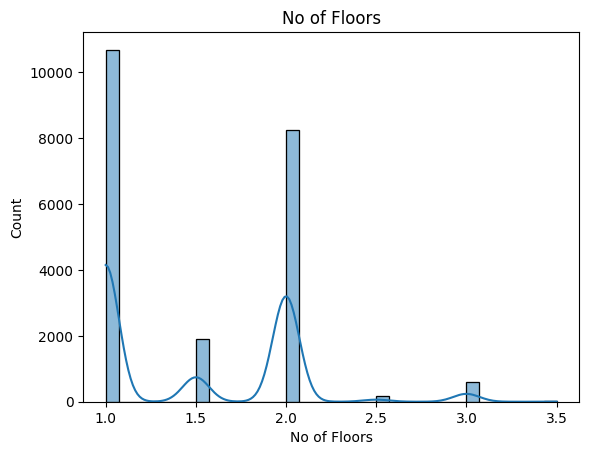

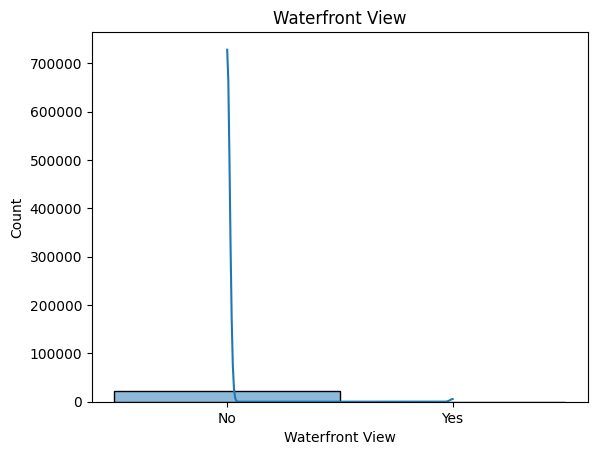

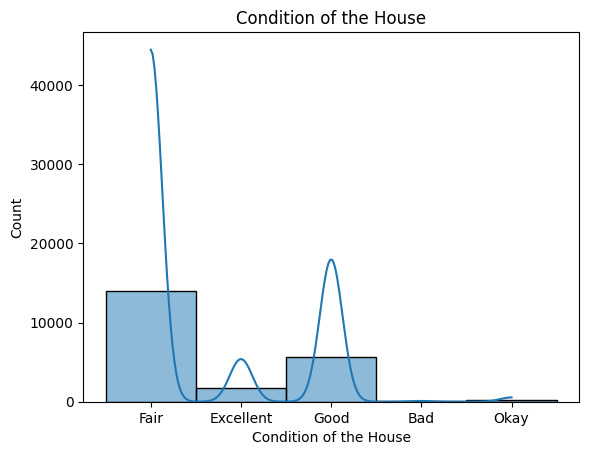

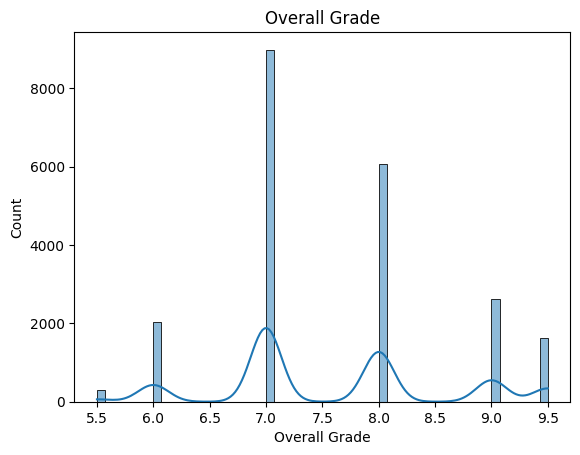

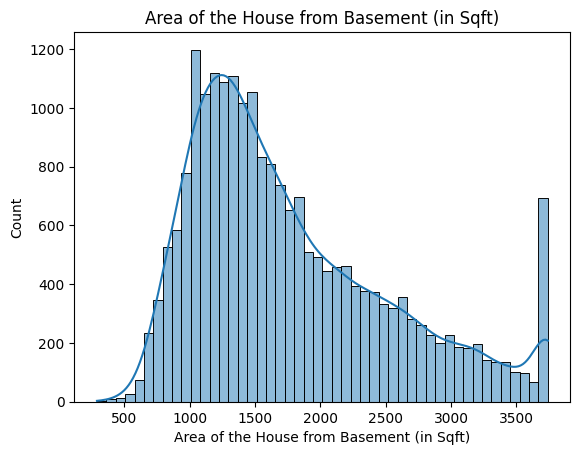

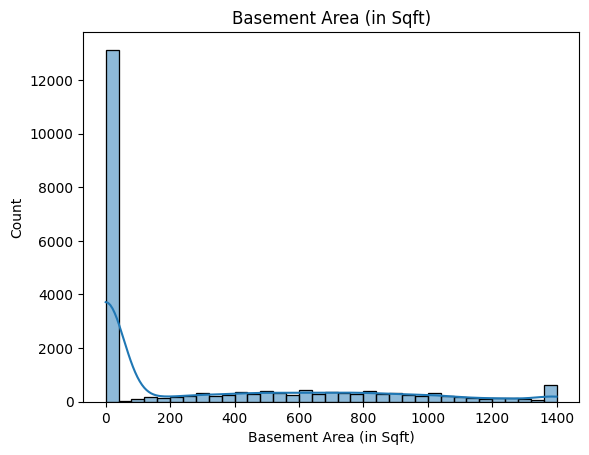

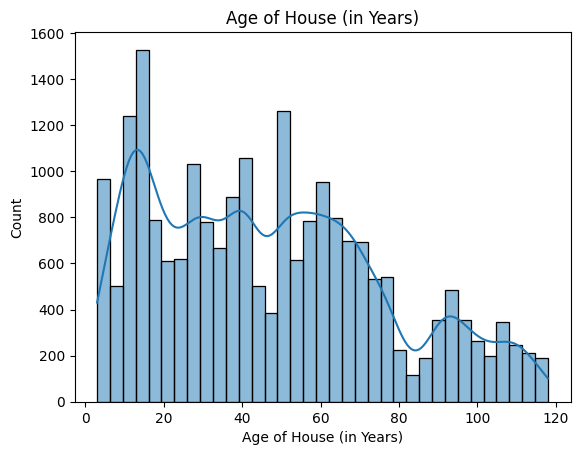

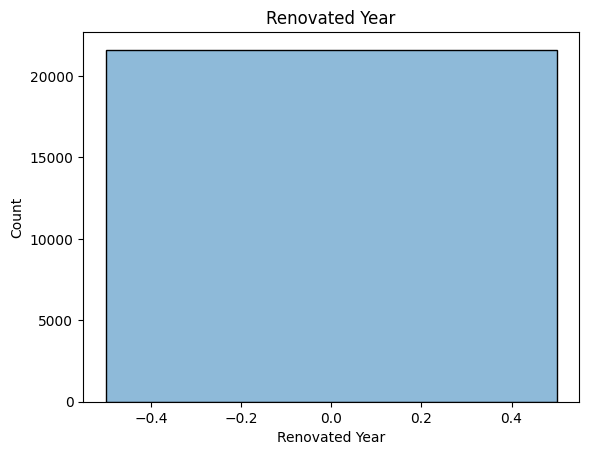

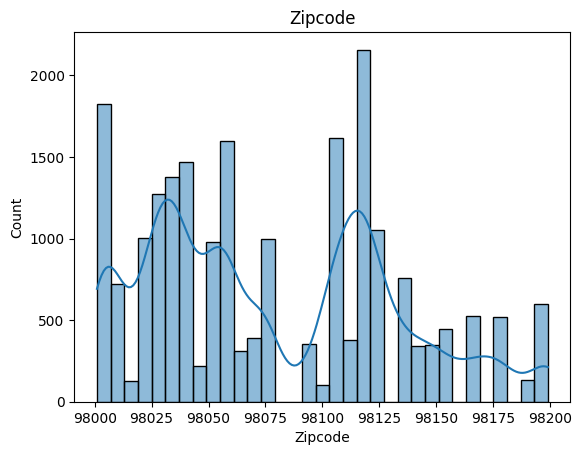

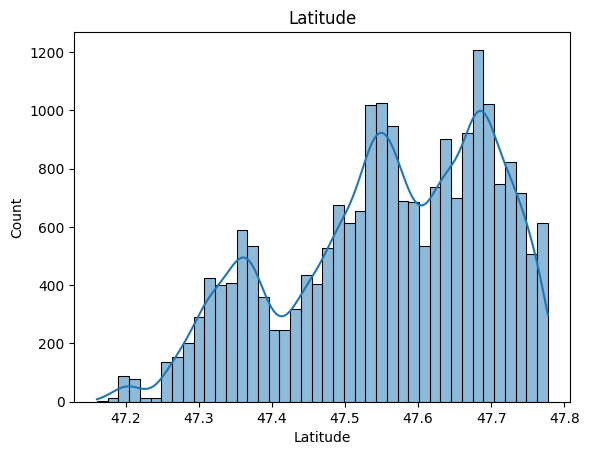

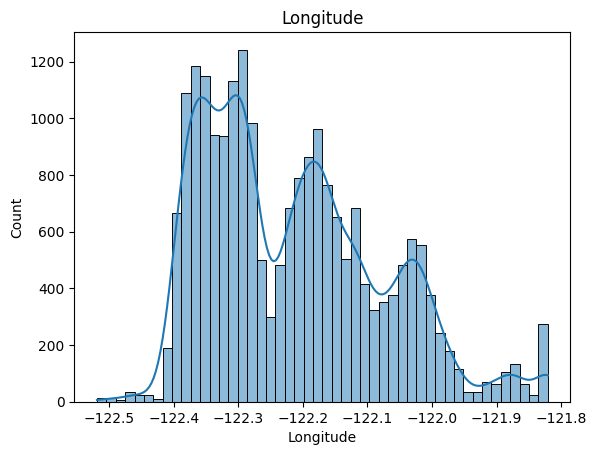

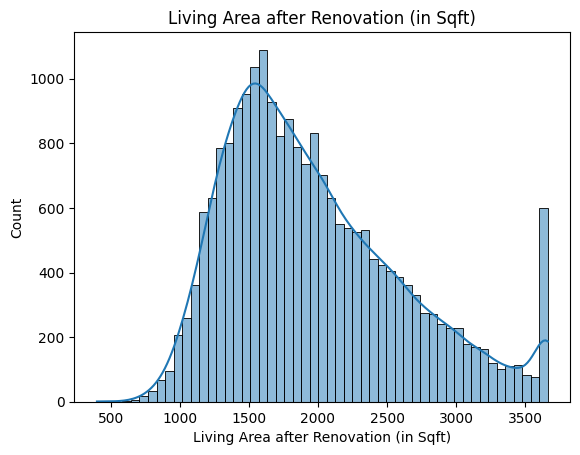

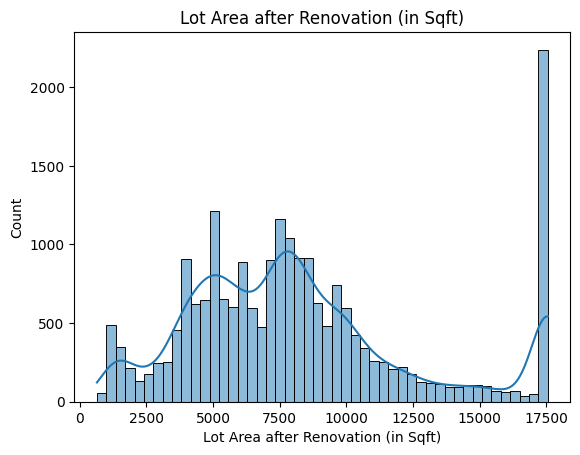

In [27]:
for columns in House_df:
  sns.histplot(House_df[columns],kde = True)
  plt.title(columns)
  plt.show()

In [28]:
skewness = House_df.select_dtypes(include=['int64','float64']).skew().sort_values(ascending=False)
print(skewness)

Basement Area (in Sqft)                      1.219021
Sale Price                                   0.936921
Area of the House from Basement (in Sqft)    0.905460
Lot Area (in Sqft)                           0.831809
Living Area after Renovation (in Sqft)       0.774202
Lot Area after Renovation (in Sqft)          0.768205
Flat Area (in Sqft)                          0.728098
Longitude                                    0.670953
No of Floors                                 0.616177
Age of House (in Years)                      0.469805
Zipcode                                      0.405769
Overall Grade                                0.275922
ID                                           0.243329
No of Bedrooms                               0.240790
No of Bathrooms                              0.043441
Renovated Year                               0.000000
Latitude                                    -0.485170
dtype: float64


In [29]:
# Log transform for highly skewed columns
log_cols = ['Sale Price', 'Lot Area (in Sqft)', 'Flat Area (in Sqft)',
            'Basement Area (in Sqft)', 'Area of the House from Basement (in Sqft)',
            'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)']

for col in log_cols:
    House_df[col] = np.log1p(House_df[col])

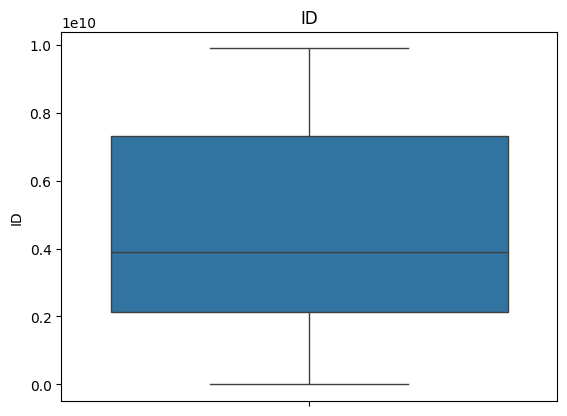

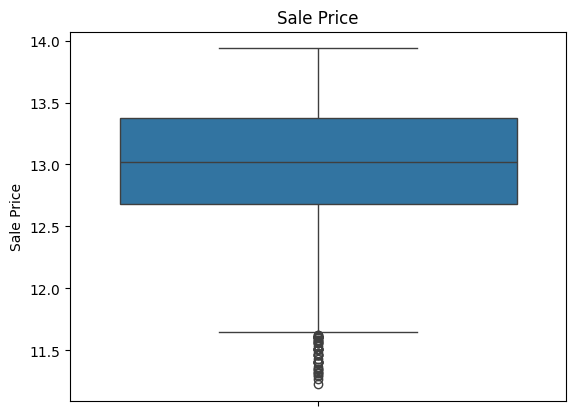

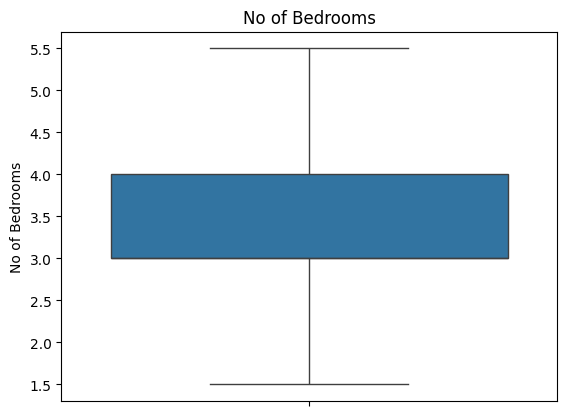

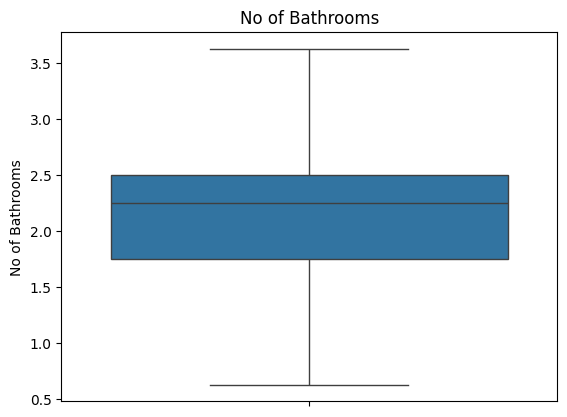

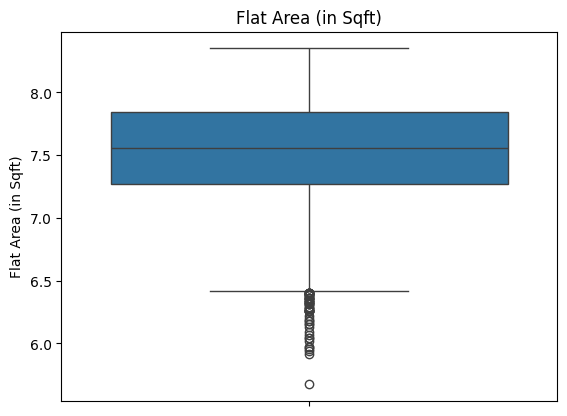

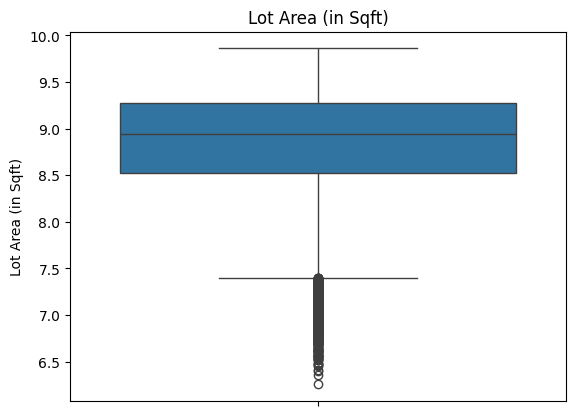

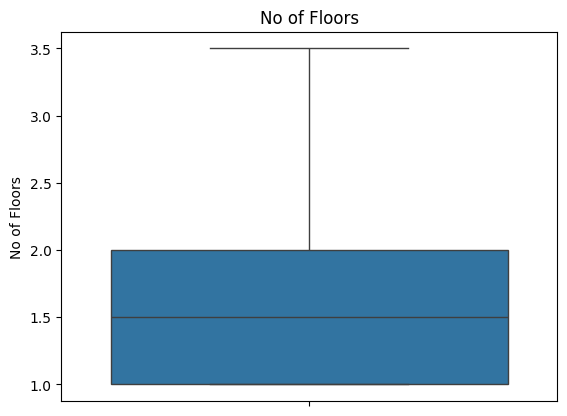

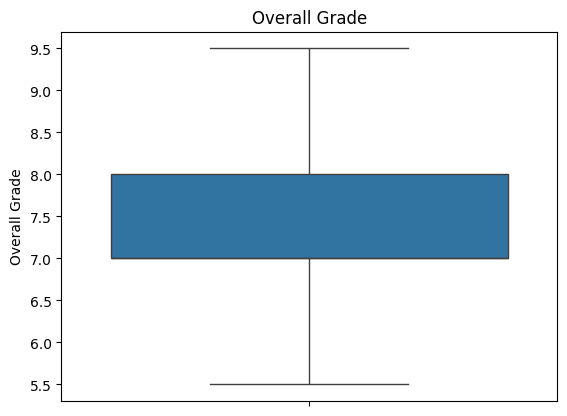

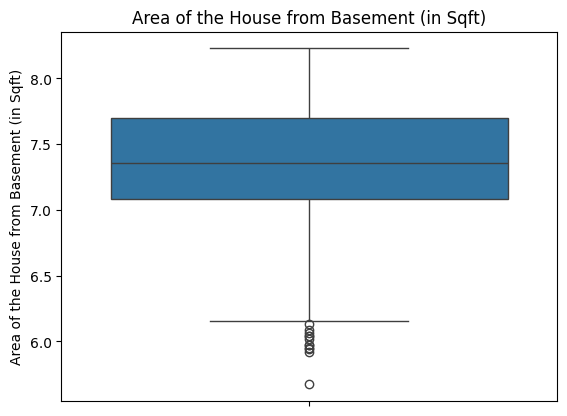

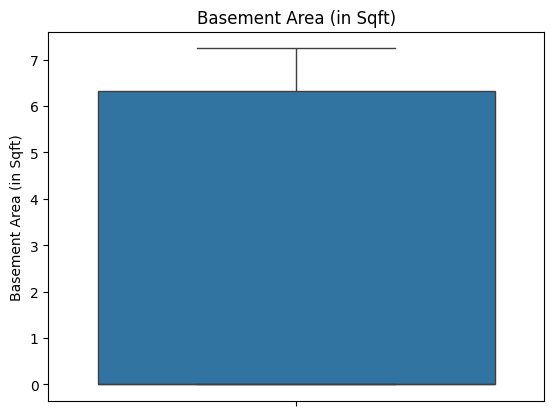

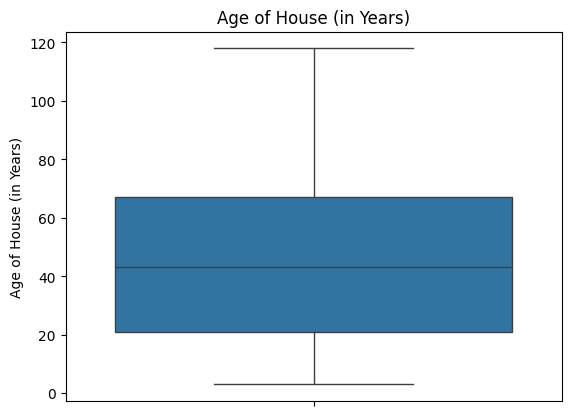

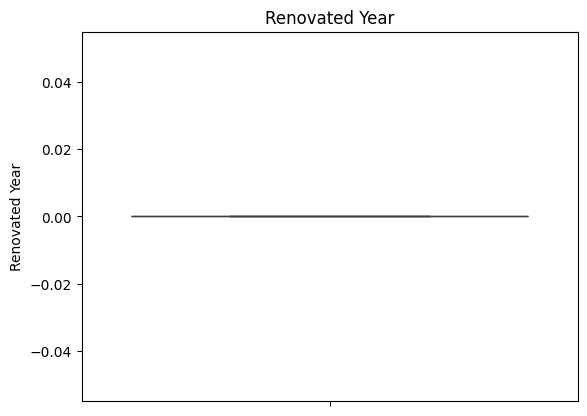

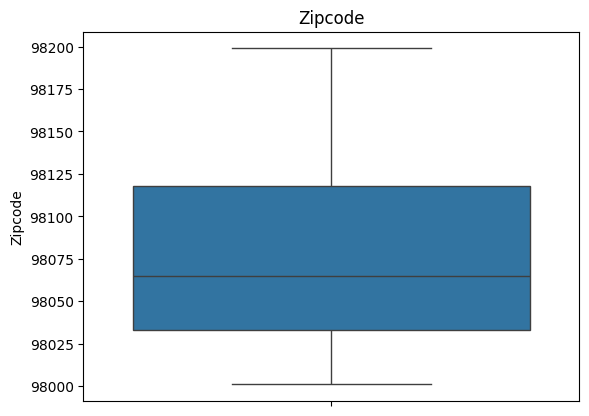

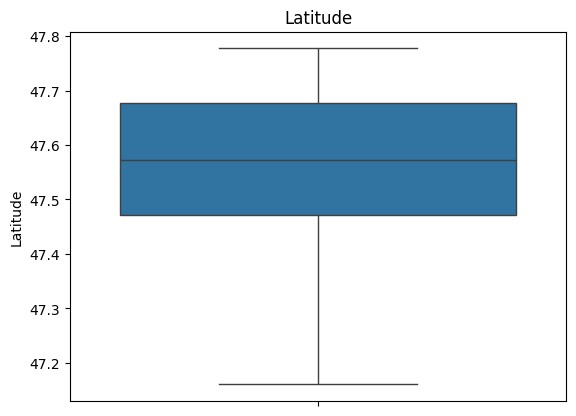

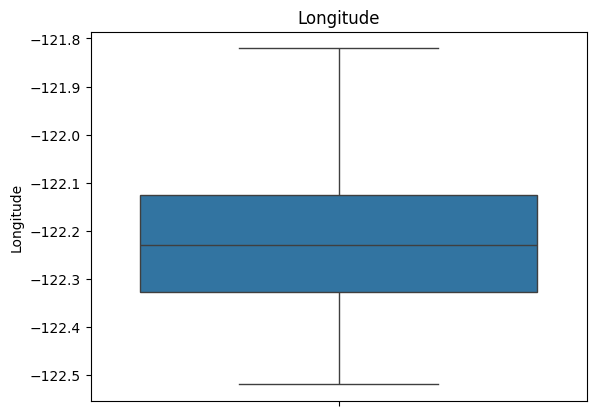

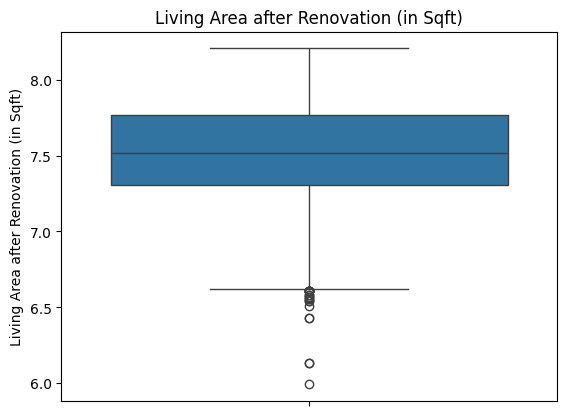

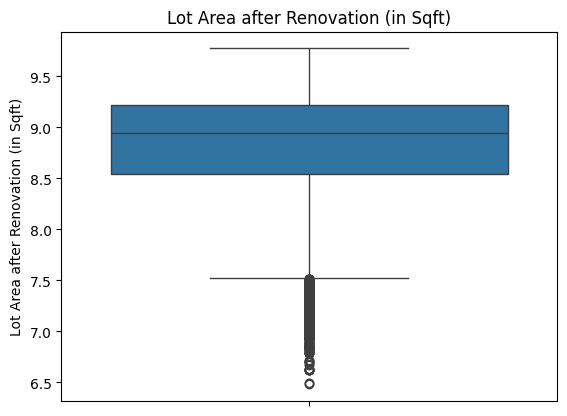

In [30]:
for col in House_df.select_dtypes(include='number').columns:
    sns.boxplot(y=House_df[col])
    plt.title(col)
    plt.show()

In [31]:
for col in House_df.select_dtypes(include='number').columns:
    Q1 = House_df[col].quantile(0.25)
    Q3 = House_df[col].quantile(0.75)
    IQR = Q3 - Q1
    House_df[col] = House_df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

In [32]:
scaler = MinMaxScaler()
num_cols = House_df.select_dtypes(include='number').columns.drop('Sale Price')

In [33]:

# Perform one-hot encoding for 'Waterfront View' and 'Condition of the House'
House_df = pd.get_dummies(House_df, columns=['Waterfront View', 'Condition of the House'], drop_first=False)

# 2. Convert boolean dummy columns to integers (0/1)
dummy_cols = ['Condition of the House_Excellent',
              'Condition of the House_Fair',
              'Condition of the House_Good',
              'Condition of the House_Okay',
              'Waterfront View_Yes']

# Ensure all specified dummy columns exist before trying to convert them
existing_dummy_cols = [col for col in dummy_cols if col in House_df.columns]
House_df[existing_dummy_cols] = House_df[existing_dummy_cols].astype(int)

print(House_df.shape)
House_df.head()

(21613, 25)


,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),...,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Waterfront View_No,Waterfront View_Yes,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,7129300520,14 October 2017,12.309987,3.0,1.00,7.074117,8.639588,1.0,7.0,7.074117,...,-122.257,7.201171,8.639588,True,0,False,0,1,0,0
1,6414100192,14 December 2017,13.195616,3.0,2.25,7.852050,8.887791,2.0,7.0,7.682943,...,-122.319,7.433075,8.941153,True,0,False,0,1,0,0
2,5631500400,15 February 2016,12.100718,2.0,1.00,6.647688,9.210440,1.0,6.0,6.647688,...,-122.233,7.908755,8.995041,True,0,False,0,1,0,0
3,2487200875,14 December 2017,13.311331,4.0,3.00,7.581210,8.517393,1.0,7.0,6.957497,...,-122.393,7.215975,8.517393,True,0,False,1,0,0,0
4,1954400510,15 February 2016,13.142168,3.0,2.00,7.427144,8.997271,1.0,8.0,7.427144,...,-122.045,7.496097,8.923191,True,0,False,0,1,0,0


In [34]:
House_df

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),...,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Waterfront View_No,Waterfront View_Yes,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,7129300520,14 October 2017,12.309987,3.0,1.00,7.074117,8.639588,1.0,7.0,7.074117,...,-122.257,7.201171,8.639588,True,0,False,0,1,0,0
1,6414100192,14 December 2017,13.195616,3.0,2.25,7.852050,8.887791,2.0,7.0,7.682943,...,-122.319,7.433075,8.941153,True,0,False,0,1,0,0
2,5631500400,15 February 2016,12.100718,2.0,1.00,6.647688,9.210440,1.0,6.0,6.647688,...,-122.233,7.908755,8.995041,True,0,False,0,1,0,0
3,2487200875,14 December 2017,13.311331,4.0,3.00,7.581210,8.517393,1.0,7.0,6.957497,...,-122.393,7.215975,8.517393,True,0,False,1,0,0,0
4,1954400510,15 February 2016,13.142168,3.0,2.00,7.427144,8.997271,1.0,8.0,7.427144,...,-122.045,7.496097,8.923191,True,0,False,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,12.793862,3.0,2.50,7.333676,7.398365,3.0,8.0,7.333676,...,-122.346,7.333676,7.514922,True,0,False,0,1,0,0
21609,6600060120,15 February 2016,12.899222,4.0,2.50,7.745436,8.668024,2.0,8.0,7.745436,...,-122.362,7.512618,8.881975,True,0,False,0,1,0,0
21610,1523300141,14 June 2017,12.904461,2.0,0.75,6.928538,7.398365,2.0,7.0,6.928538,...,-122.299,6.928538,7.604894,True,0,False,0,1,0,0
21611,291310100,15 January 2016,12.899222,3.0,2.50,7.378384,7.778630,2.0,8.0,7.378384,...,-122.069,7.252054,7.514922,True,0,False,0,1,0,0


In [35]:
X = House_df.drop(columns=['Sale Price', 'Date House was Sold'])
y = House_df['Sale Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(17290, 23) (4323, 23)


# MODEL BUILDING

### 4 different supervised machine learning algorithms

1) Decision Tree

In [36]:
# Building the Model Object
dT_model = DecisionTreeRegressor()

# Train the model
dT_model.fit(X_train, y_train)

# Making Predictions using the model
y_pred_DT = dT_model.predict(X_test)

# Evaluating the model performance
# Our target column is numerical, hence we will use regression, where errors are calculated, not accuracy
print("Decision Tree Evaluation")
print(45 * "-")
print("Mean Absolute Error \t\t: ", mean_absolute_error(y_test, y_pred_DT))
print("Mean squared Error \t\t: ", mean_squared_error(y_test, y_pred_DT))
print("sqrt of Mean squared Error \t: ", np.sqrt(mean_squared_error(y_test, y_pred_DT)))
print("R2 score \t\t\t: ", r2_score(y_test, y_pred_DT))

Decision Tree Evaluation
---------------------------------------------
Mean Absolute Error 		:  0.16777864316787824
Mean squared Error 		:  0.05684796793893104
sqrt of Mean squared Error 	:  0.2384281190189845
R2 score 			:  0.7582390301149511


###
2.decision tree

In [37]:
# Building the Model Object
LR_model = LinearRegression()

# Train the model
LR_model.fit(X_train, y_train)

# Making Predictions using the model
y_pred_LR = dT_model.predict(X_test)

# Evaluating the model performance
# Our target column is numerical, hence we will use regression, where errors are calculated, not accuracy
print("Linear Regression Evaluation")
print(45 * "-")
print("Mean Absolute Error \t\t: ", mean_absolute_error(y_test, y_pred_LR))
print("Mean squared Error \t\t: ", mean_squared_error(y_test, y_pred_LR))
print("sqrt of Mean squared Error \t: ", np.sqrt(mean_squared_error(y_test, y_pred_LR)))
print("R2 score \t\t\t: ", r2_score(y_test, y_pred_LR))

Linear Regression Evaluation
---------------------------------------------
Mean Absolute Error 		:  0.16777864316787824
Mean squared Error 		:  0.05684796793893104
sqrt of Mean squared Error 	:  0.2384281190189845
R2 score 			:  0.7582390301149511


###
3.Random Tree

In [38]:
# Random Forest combines multiple decision trees
# to improve prediction accuracy

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict using test data
rf_pred = rf_model.predict(X_test)

# Evaluate model performance
print("Random Forest Results")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest Results
MAE : 0.119970274145549
MSE : 0.02876549062223496
RMSE : 0.16960392277961897
R2 Score : 0.8776671679888094


###
3.KNN

In [41]:
knn_model = KNeighborsRegressor(
    n_neighbors=5
)

# Train the model
knn_model.fit(X_train, y_train)

# Predict using test data
knn_pred = knn_model.predict(X_test)

# Evaluate model performance
print("KNN Results")
print("MAE :", mean_absolute_error(y_test, knn_pred))
print("MSE :", mean_squared_error(y_test, knn_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, knn_pred)))
print("R2 Score :", r2_score(y_test, knn_pred))

KNN Results
MAE : 0.2582570048942434
MSE : 0.12730427057813082
RMSE : 0.35679724014926295
R2 Score : 0.45860502949656823


In [47]:
# Store all model results in a DataFrame
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],

    "R2 Score": [
        r2_score(y_test, y_pred_LR),
        r2_score(y_test, y_pred_DT),
        r2_score(y_test, rf_pred),
        r2_score(y_test, knn_pred)
    ]
})

# Display model comparison table
results

,Model,R2 Score
0,Linear Regression,0.758239
1,Decision Tree,0.758239
2,Random Forest,0.877667
3,KNN,0.458605
